> **Repository note.** Development notebook: matched-count control and bootstrap pilot.
> This notebook is preserved with executed outputs from the research run. Large embedding caches and third-party datasets are intentionally not bundled. See `REPRODUCIBILITY.md` at the repository root.


# Semantic Disambiguation Geometry — V2
## Does informative context contract a sense cloud, separate senses, or enrich contextual variation?

This version fixes the main problems found in the first pilot:

1. **Sampling bug fixed**  
   Sampling is now grouped by **`word × sense`**, not by label IDs shared across words.

2. **Balanced per-word sense samples**  
   Every analyzed word contributes the same number of examples per sense (up to a cap), avoiding unstable centroids caused by 18:2 or 3:4 samples.

3. **No `stage=0` inference**  
   The fully masked sentence leaked sentence length/position/punctuation and produced misleading "uncertainty".  
   The main experiment now compares **informative vs random context at exactly the same reveal count**.

4. **No full-context-calibrated entropy applied to masked inputs**  
   Sense resolution is measured with **stage-matched prototypes** built from training variants of the same condition.

5. **Matched-count analysis is primary**  
   At each \(k\), the sentence, number of visible tokens, number of masks, target token, encoder, and examples are identical. Only **which context tokens are revealed** changes.

6. **Paired uncertainty estimates added**  
   Main effects are reported as paired per-word differences plus bootstrap confidence intervals over words.

---

## Main question

For each ambiguous word and reveal count \(k\):

\[
\Delta W_k
=
W_{\text{informative},k}
-
W_{\text{random},k}
\]

\[
\Delta B_k
=
B_{\text{informative},k}
-
B_{\text{random},k}
\]

where:

- \(W\): within-sense dispersion,
- \(B\): between-sense centroid separation.

Competing hypotheses:

### Contraction
\[
\Delta W_k < 0
\]

### Separation
\[
\Delta W_k \approx 0,
\qquad
\Delta B_k > 0
\]

### Contextual enrichment + separation
\[
\Delta W_k > 0,
\qquad
\Delta B_k > 0
\]

Sense decodability must also improve under informative context; otherwise the geometric difference is not interpreted as disambiguation.

In [1]:
# Kaggle / Colab setup
!pip -q install "datasets>=2.18,<4" "transformers>=4.43,<5" accelerate scipy scikit-learn pandas pyarrow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


In [2]:
import math
import json
import random
import hashlib
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score, f1_score

from scipy.spatial.distance import pdist
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


## Configuration

`pilot` uses six ambiguous nouns.  
`full` uses all 20 CoarseWSD-20 nouns.

The test set is balanced **within each word** by undersampling every sense to the size of that word's rarest sense, subject to a cap.

This deliberately trades some data volume for reliable, interpretable sense-cloud comparisons.

In [3]:
RUN_MODE = "pilot"  # "pilot" or "full"

DATASET_ID = "kiamehr74/CoarseWSD-20"
MODEL_NAME = "bert-base-uncased"

ALL_WORDS = [
    "apple", "arm", "bank", "bass", "bow",
    "chair", "club", "crane", "deck", "digit",
    "hood", "java", "mole", "pitcher", "pound",
    "seal", "spring", "square", "trunk", "yard",
]

if RUN_MODE == "pilot":
    WORDS = ["bank", "bass", "crane", "java", "mole", "spring"]
    MAX_TRAIN_PER_SENSE = 180
    MAX_TEST_PER_SENSE = 100
else:
    WORDS = ALL_WORDS
    MAX_TRAIN_PER_SENSE = 250
    MAX_TEST_PER_SENSE = 120

MIN_TRAIN_PER_SENSE = 20
MIN_TEST_PER_SENSE = 15

# No stage 0. Main inference is matched-count informative vs random.
REVEAL_COUNTS = [1, 2, 4, 8, 16]

# "gold_pmi" is an oracle intervention using the gold sense only to choose
# which context evidence is revealed. It is NOT a deployable WSD system.
STRATEGIES = ["gold_pmi", "local", "random"]

LAYERS_TO_SAVE = [4, 8, 12]
MAIN_LAYER = 12

MAX_WORDS = 96
ENCODE_BATCH_SIZE = 64

BOOTSTRAP_ITERS = 5000

OUTPUT_DIR = Path("semantic_disambiguation_geometry_v2_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("mode:", RUN_MODE)
print("words:", WORDS)
print("reveal counts:", REVEAL_COUNTS)

mode: pilot
words: ['bank', 'bass', 'crane', 'java', 'mole', 'spring']
reveal counts: [1, 2, 4, 8, 16]


## Load CoarseWSD-20

We retain the official train/test split and the dataset's target-word index.

The first pilot accidentally grouped examples only by `label`, but every word reuses labels `0,1,...`.  
V2 always groups by **`["word", "label"]`**.

In [4]:
def crop_around_target(tokens, target_idx, max_words=96):
    if len(tokens) <= max_words:
        return tokens, target_idx

    half = max_words // 2
    left = max(0, target_idx - half)
    right = min(len(tokens), left + max_words)
    left = max(0, right - max_words)

    return tokens[left:right], target_idx - left


def load_word_config(word):
    ds = load_dataset(DATASET_ID, word, trust_remote_code=True)
    label_names = ds["train"].features["label"].names

    frames = []

    for split in ["train", "test"]:
        d = ds[split].to_pandas()
        d["word"] = word
        d["split"] = split
        d["sense_name"] = d["label"].map(dict(enumerate(label_names)))

        token_lists = []
        target_indices = []
        valid = []

        for _, row in d.iterrows():
            toks = str(row["sentence"]).split()
            idx = int(row["idx"])

            if not (0 <= idx < len(toks)):
                token_lists.append([])
                target_indices.append(-1)
                valid.append(False)
                continue

            toks, idx = crop_around_target(toks, idx, MAX_WORDS)
            target_surface = toks[idx].lower().strip('.,;:!?()[]{}"')

            token_lists.append(toks)
            target_indices.append(idx)
            valid.append(
                word.lower() in target_surface
                or target_surface in word.lower()
            )

        d["tokens"] = token_lists
        d["target_idx"] = target_indices
        d["target_check"] = valid
        d["example_id"] = [
            f"{word}:{split}:{i}"
            for i in range(len(d))
        ]

        frames.append(d)

    return pd.concat(frames, ignore_index=True)


all_df = pd.concat(
    [
        load_word_config(w)
        for w in tqdm(WORDS, desc="loading CoarseWSD-20")
    ],
    ignore_index=True,
)

assert all_df["target_check"].all(), "Target index sanity check failed."

counts = (
    all_df
    .groupby(["word", "split", "sense_name"])
    .size()
    .rename("n")
    .reset_index()
)

display(counts)

loading CoarseWSD-20:   0%|          | 0/6 [00:00<?, ?it/s]

CoarseWSD-20.py: 0.00B [00:00, ?B/s]

0000.parquet:   0%|          | 0.00/128k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/52.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1107 [00:00<?, ? examples/s]

...

0000.parquet:   0%|          | 0.00/110k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/48.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1064 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/457 [00:00<?, ? examples/s]

,word,split,sense_name,n
0,bank,test,bank_bank,433
1,bank,test,bank_bank_(geography),22
2,bank,train,bank_bank,1061
3,bank,train,bank_bank_(geography),46
4,bass,test,bass_bass_(voice_type),298
5,bass,test,bass_bass_guitar,1005
6,bass,test,bass_double_bass,88
7,bass,train,bass_bass_(voice_type),609
8,bass,train,bass_bass_guitar,2356
9,bass,train,bass_double_bass,208


## Balanced sampling — fixed

For each word separately:

\[
n_w
=
\min(
	ext{cap},
\min_s n_{w,s}
)
\]

and exactly \(n_w\) examples are sampled from **every sense** of that word.

Words with too few examples in their rarest sense are excluded and printed explicitly.

In [5]:
def balanced_sample_per_word(
    df,
    cap_per_sense,
    min_per_sense,
    seed=SEED,
):
    parts = []
    kept = []
    dropped = []

    for word, gw in df.groupby("word", sort=True):
        sense_counts = gw.groupby("label").size()
        n = min(int(sense_counts.min()), int(cap_per_sense))

        if n < min_per_sense:
            dropped.append({
                "word": word,
                "min_available": int(sense_counts.min()),
                "required": int(min_per_sense),
            })
            continue

        for label, gs in gw.groupby("label", sort=True):
            # Different deterministic seed per word/sense.
            h = int(
                hashlib.md5(
                    f"{seed}|{word}|{int(label)}".encode()
                ).hexdigest()[:8],
                16,
            )
            parts.append(
                gs.sample(n=n, random_state=h)
            )

        kept.append({
            "word": word,
            "n_per_sense": n,
            "n_senses": len(sense_counts),
            "total": n * len(sense_counts),
        })

    if not parts:
        raise RuntimeError("No words satisfy the minimum sample threshold.")

    out = pd.concat(parts, ignore_index=True)

    return (
        out,
        pd.DataFrame(kept),
        pd.DataFrame(dropped),
    )


train_all = all_df[all_df["split"] == "train"].copy()
test_all = all_df[all_df["split"] == "test"].copy()

train_df, train_sampling, train_dropped = balanced_sample_per_word(
    train_all,
    MAX_TRAIN_PER_SENSE,
    MIN_TRAIN_PER_SENSE,
)

test_df, test_sampling, test_dropped = balanced_sample_per_word(
    test_all,
    MAX_TEST_PER_SENSE,
    MIN_TEST_PER_SENSE,
)

VALID_WORDS = sorted(
    set(train_df["word"]) & set(test_df["word"])
)

train_df = train_df[
    train_df["word"].isin(VALID_WORDS)
].reset_index(drop=True)

test_df = test_df[
    test_df["word"].isin(VALID_WORDS)
].reset_index(drop=True)

print("VALID_WORDS:", VALID_WORDS)

print("\nTRAIN sampling")
display(train_sampling[train_sampling["word"].isin(VALID_WORDS)])

print("\nTEST sampling")
display(test_sampling[test_sampling["word"].isin(VALID_WORDS)])

if len(train_dropped):
    print("\nDropped from train:")
    display(train_dropped)

if len(test_dropped):
    print("\nDropped from test:")
    display(test_dropped)

print("\nFinal balanced test counts:")
display(
    test_df
    .groupby(["word", "sense_name"])
    .size()
    .rename("n")
    .reset_index()
)

VALID_WORDS: ['bank', 'bass', 'crane', 'java', 'mole', 'spring']

TRAIN sampling


,word,n_per_sense,n_senses,total
0,bank,46,2,92
1,bass,180,3,540
2,crane,161,2,322
3,java,180,2,360
4,mole,51,5,255
5,spring,159,3,477



TEST sampling


,word,n_per_sense,n_senses,total
0,bank,22,2,44
1,bass,88,3,264
2,crane,76,2,152
3,java,100,2,200
4,mole,20,5,100
5,spring,73,3,219



Final balanced test counts:


,word,sense_name,n
0,bank,bank_bank,22
1,bank,bank_bank_(geography),22
2,bass,bass_bass_(voice_type),88
3,bass,bass_bass_guitar,88
4,bass,bass_double_bass,88
5,crane,crane_crane_(bird),76
6,crane,crane_crane_(machine),76
7,java,java_java,100
8,java,java_java_(programming_language),100
9,mole,mole_mole_(animal),20


## Oracle informative-token ranking

The experiment needs a controlled way to reveal context that is genuinely diagnostic of the gold sense.

Using the **official training set only**, we estimate document-frequency PMI:

\[
\operatorname{PMI}(t,s)
=
\log \frac{P(t\mid s)}{P(t)}.
\]

Rare one-off tokens are excluded from the ranking table.

Important: `gold_pmi` is an **oracle experimental intervention**.  
Gold labels are never used by the frozen encoder; they are only used to choose which tokens become visible.

Primary comparisons are against `random` at the same visible-token count.

In [6]:
PUNCT = set(".,;:!?()[]{}\"'`-–—")


def norm_token(t):
    return t.lower().strip(".,;:!?()[]{}\"'`")


def is_punctuation_token(t):
    s = t.strip()
    return len(s) > 0 and all(ch in PUNCT for ch in s)


def build_pmi_tables(df, alpha=0.5, min_total_df=2):
    tables = {}

    for word, g in df.groupby("word"):
        n_all = len(g)
        labels = sorted(g["label"].astype(int).unique())

        all_dfreq = Counter()
        sense_dfreq = {
            int(lab): Counter()
            for lab in labels
        }
        n_sense = Counter(g["label"].astype(int))

        for _, row in g.iterrows():
            target_idx = int(row["target_idx"])
            seen = set()

            for i, tok in enumerate(row["tokens"]):
                if i == target_idx:
                    continue

                nt = norm_token(tok)

                if not nt or is_punctuation_token(tok):
                    continue
                if nt == word.lower():
                    continue

                seen.add(nt)

            all_dfreq.update(seen)
            sense_dfreq[int(row["label"])].update(seen)

        vocab = {
            tok
            for tok, c in all_dfreq.items()
            if c >= min_total_df
        }

        word_table = {}

        for lab in labels:
            lab = int(lab)
            scores = {}

            for tok in vocab:
                p_ts = (
                    sense_dfreq[lab][tok] + alpha
                ) / (
                    n_sense[lab] + 2 * alpha
                )

                p_t = (
                    all_dfreq[tok] + alpha
                ) / (
                    n_all + 2 * alpha
                )

                scores[tok] = math.log(p_ts / p_t)

            word_table[lab] = scores

        tables[word] = word_table

    return tables


# Use all official training examples, never test examples.
PMI_TABLES = build_pmi_tables(
    train_all[train_all["word"].isin(VALID_WORDS)]
)

print("PMI tables:", list(PMI_TABLES))

PMI tables: ['bank', 'bass', 'crane', 'java', 'mole', 'spring']


## Matched-count context variants

At a given \(k\):

- same original sentence,
- same target token,
- same target position,
- same sentence length,
- same number of visible context tokens,
- same number of `[MASK]` tokens.

Only **which \(k\) context tokens are visible** changes.

This makes `gold_pmi(k)` vs `random(k)` the cleanest V2 comparison.

In [7]:
def context_positions(tokens, target_idx):
    return [
        i
        for i, tok in enumerate(tokens)
        if i != target_idx
        and not is_punctuation_token(tok)
    ]


def rank_positions(row, strategy):
    tokens = row["tokens"]
    target_idx = int(row["target_idx"])
    positions = context_positions(tokens, target_idx)

    if strategy == "local":
        return sorted(
            positions,
            key=lambda i: (abs(i - target_idx), i),
        )

    if strategy == "random":
        seed = int(
            hashlib.md5(
                f"{SEED}|{row['example_id']}".encode()
            ).hexdigest()[:8],
            16,
        )
        rng = random.Random(seed)
        positions = positions.copy()
        rng.shuffle(positions)
        return positions

    if strategy == "gold_pmi":
        scores = PMI_TABLES[row["word"]][int(row["label"])]

        return sorted(
            positions,
            key=lambda i: scores.get(
                norm_token(tokens[i]),
                -999.0,
            ),
            reverse=True,
        )

    raise ValueError(strategy)


def make_masked_variant(
    row,
    strategy,
    reveal_k,
    mask_token,
):
    tokens = list(row["tokens"])
    target_idx = int(row["target_idx"])

    ranked = rank_positions(row, strategy)
    reveal = set(ranked[:reveal_k])

    out = []

    for i, tok in enumerate(tokens):
        if i == target_idx:
            out.append(tok)
        elif is_punctuation_token(tok):
            out.append(tok)
        elif i in reveal:
            out.append(tok)
        else:
            out.append(mask_token)

    return out, len(reveal), len(ranked)


def build_variants(df, mask_token):
    records = []

    keep = [
        "example_id",
        "word",
        "label",
        "sense_name",
        "target_idx",
    ]

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="building variants",
    ):
        base = row.to_dict()

        for strategy in STRATEGIES:
            for stage_order, k in enumerate(REVEAL_COUNTS):
                toks, actual, total = make_masked_variant(
                    row,
                    strategy,
                    k,
                    mask_token,
                )

                rec = {
                    key: base[key]
                    for key in keep
                }

                rec.update({
                    "strategy": strategy,
                    "reveal_k": int(k),
                    "stage_order": stage_order,
                    "actual_reveal": actual,
                    "available_context": total,
                    "tokens_variant": toks,
                })

                records.append(rec)

    return pd.DataFrame(records)

## Frozen contextual encoder

Layers 4, 8, and 12 are collected in one forward pass.  
For a target split into multiple WordPieces, all target subword vectors are averaged.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
)

model.to(DEVICE)
model.eval()

assert tokenizer.mask_token is not None

print("mask token:", tokenizer.mask_token)
print("hidden size:", model.config.hidden_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

mask token: [MASK]
hidden size: 768


In [9]:
@torch.inference_mode()
def encode_target_tokens(
    token_lists,
    target_indices,
    layers=LAYERS_TO_SAVE,
    batch_size=ENCODE_BATCH_SIZE,
):
    outputs = {
        layer: []
        for layer in layers
    }

    for start in tqdm(
        range(0, len(token_lists), batch_size),
        desc="encoding",
    ):
        btok = token_lists[start:start + batch_size]
        bidx = target_indices[start:start + batch_size]

        enc = tokenizer(
            btok,
            is_split_into_words=True,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )

        word_ids = [
            enc.word_ids(batch_index=i)
            for i in range(len(btok))
        ]

        enc_gpu = {
            k: v.to(DEVICE)
            for k, v in enc.items()
        }

        out = model(**enc_gpu)

        for layer in layers:
            h = out.hidden_states[layer]
            vecs = []

            for b, target_word_idx in enumerate(bidx):
                positions = [
                    j
                    for j, wid in enumerate(word_ids[b])
                    if wid == int(target_word_idx)
                ]

                if not positions:
                    raise RuntimeError(
                        "Target token was truncated unexpectedly."
                    )

                vecs.append(
                    h[b, positions, :].mean(dim=0)
                )

            outputs[layer].append(
                torch.stack(vecs)
                .float()
                .cpu()
                .numpy()
            )

    return {
        layer: np.concatenate(chunks, axis=0)
        for layer, chunks in outputs.items()
    }


def l2_normalize_rows(x, eps=1e-12):
    norms = np.linalg.norm(
        x,
        axis=1,
        keepdims=True,
    )
    return x / np.maximum(norms, eps)

## Build and encode both train and test variants

V1 used full-context sense prototypes to score heavily masked examples.  
V2 instead builds **stage-matched training variants**, so every test condition is compared against prototypes generated under the same:

- reveal strategy,
- reveal count,
- BERT layer.

In [10]:
train_variants = build_variants(
    train_df,
    tokenizer.mask_token,
)

test_variants = build_variants(
    test_df,
    tokenizer.mask_token,
)

print("train variants:", len(train_variants))
print("test variants :", len(test_variants))

train_embeddings = encode_target_tokens(
    train_variants["tokens_variant"].tolist(),
    train_variants["target_idx"].astype(int).tolist(),
)

test_embeddings = encode_target_tokens(
    test_variants["tokens_variant"].tolist(),
    test_variants["target_idx"].astype(int).tolist(),
)

for layer in LAYERS_TO_SAVE:
    train_embeddings[layer] = l2_normalize_rows(
        train_embeddings[layer]
    )
    test_embeddings[layer] = l2_normalize_rows(
        test_embeddings[layer]
    )

print({
    layer: (
        train_embeddings[layer].shape,
        test_embeddings[layer].shape,
    )
    for layer in LAYERS_TO_SAVE
})

building variants:   0%|          | 0/2046 [00:00<?, ?it/s]

building variants:   0%|          | 0/979 [00:00<?, ?it/s]

train variants: 30690
test variants : 14685


encoding:   0%|          | 0/480 [00:00<?, ?it/s]

encoding:   0%|          | 0/230 [00:00<?, ?it/s]

{4: ((30690, 768), (14685, 768)), 8: ((30690, 768), (14685, 768)), 12: ((30690, 768), (14685, 768))}


## Stage-matched sense decodability

For every:

\[
(\text{word}, \text{layer}, \text{strategy}, k)
\]

we build normalized sense centroids from the **training variants of that exact condition**.

Test vectors are assigned to the nearest centroid by cosine similarity.

We report:

- balanced accuracy,
- macro-F1,
- gold-vs-best-other cosine margin.

This is a simple, fixed-capacity diagnostic of whether the revealed evidence really makes the gold sense easier to recover.

No cross-condition entropy calibration is used.

In [11]:
def stage_matched_decodability(
    train_meta,
    test_meta,
    train_emb,
    test_emb,
):
    records = []

    group_cols = [
        "word",
        "strategy",
        "reveal_k",
    ]

    for key, gtest in test_meta.groupby(
        group_cols,
        sort=False,
    ):
        word, strategy, reveal_k = key

        gtrain = train_meta[
            (train_meta["word"] == word)
            & (train_meta["strategy"] == strategy)
            & (train_meta["reveal_k"] == reveal_k)
        ]

        labels = sorted(
            gtrain["label"].astype(int).unique()
        )

        centroids = []

        for lab in labels:
            idx = gtrain.index[
                gtrain["label"].astype(int) == lab
            ].to_numpy()

            c = train_emb[idx].mean(axis=0)
            c = c / max(np.linalg.norm(c), 1e-12)
            centroids.append(c)

        centroids = np.stack(centroids)

        test_idx = gtest.index.to_numpy()
        x = test_emb[test_idx]

        sims = x @ centroids.T
        pred_col = sims.argmax(axis=1)

        pred = np.array([
            labels[j]
            for j in pred_col
        ])

        gold = (
            gtest["label"]
            .astype(int)
            .to_numpy()
        )

        label_to_col = {
            lab: j
            for j, lab in enumerate(labels)
        }

        gold_col = np.array([
            label_to_col[y]
            for y in gold
        ])

        gold_sim = sims[
            np.arange(len(sims)),
            gold_col,
        ]

        others = sims.copy()
        others[
            np.arange(len(sims)),
            gold_col,
        ] = -np.inf

        margin = gold_sim - others.max(axis=1)

        records.append({
            "word": word,
            "strategy": strategy,
            "reveal_k": int(reveal_k),
            "balanced_accuracy": balanced_accuracy_score(
                gold,
                pred,
            ),
            "macro_f1": f1_score(
                gold,
                pred,
                average="macro",
            ),
            "mean_gold_margin": float(
                margin.mean()
            ),
        })

    return pd.DataFrame(records)

## Geometry metrics

### Within-sense dispersion

\[
W
=
\frac{1}{|\mathcal S|}
\sum_s
\mathbb E_{i<j\,;\,S_i=S_j=s}
[1-\cos(h_i,h_j)]
\]

### Between-sense separation

\[
B
=
\mathbb E_{s<t}
[1-\cos(\mu_s,\mu_t)]
\]

### Separation ratio

\[
R = \frac{B}{W+\epsilon}
\]

Pairwise cosine dispersion is invariant to a common rotation/translation-like directional movement of a sense cloud, so a mean-direction shift is not mislabeled as contraction.

In [12]:
def mean_pairwise_cosine_distance(x):
    if len(x) < 2:
        return np.nan

    return float(
        np.mean(
            pdist(x, metric="cosine")
        )
    )


def effective_rank_centered(x, eps=1e-12):
    if len(x) < 3:
        return np.nan

    xc = x - x.mean(
        axis=0,
        keepdims=True,
    )

    s = np.linalg.svd(
        xc,
        compute_uv=False,
        full_matrices=False,
    )

    energy = s ** 2

    if energy.sum() <= eps:
        return 1.0

    p = energy / energy.sum()
    p = p[p > eps]

    return float(
        np.exp(
            -(p * np.log(p)).sum()
        )
    )


def cloud_metrics(x, labels):
    labels = np.asarray(labels)
    senses = sorted(np.unique(labels))

    within = []
    centroids = []

    for s in senses:
        xs = x[labels == s]

        within.append(
            mean_pairwise_cosine_distance(xs)
        )

        c = xs.mean(axis=0)
        c = c / max(
            np.linalg.norm(c),
            1e-12,
        )
        centroids.append(c)

    centroids = np.stack(centroids)

    between = float(
        np.mean(
            pdist(
                centroids,
                metric="cosine",
            )
        )
    )

    within_macro = float(
        np.nanmean(within)
    )

    return {
        "within_dispersion": within_macro,
        "between_separation": between,
        "separation_ratio": (
            between
            / max(within_macro, 1e-12)
        ),
        "effective_rank": effective_rank_centered(x),
    }

In [13]:
decodability_frames = []
geometry_records = []

for layer in LAYERS_TO_SAVE:
    dec = stage_matched_decodability(
        train_variants,
        test_variants,
        train_embeddings[layer],
        test_embeddings[layer],
    )
    dec["layer"] = layer
    decodability_frames.append(dec)

    for key, g in test_variants.groupby(
        ["word", "strategy", "reveal_k"],
        sort=False,
    ):
        word, strategy, reveal_k = key

        idx = g.index.to_numpy()
        x = test_embeddings[layer][idx]
        y = g["label"].astype(int).to_numpy()

        geometry_records.append({
            "word": word,
            "strategy": strategy,
            "reveal_k": int(reveal_k),
            "layer": layer,
            "n": len(g),
            **cloud_metrics(x, y),
        })

decodability = pd.concat(
    decodability_frames,
    ignore_index=True,
)

geometry = pd.DataFrame(
    geometry_records
)

summary = geometry.merge(
    decodability,
    on=[
        "word",
        "strategy",
        "reveal_k",
        "layer",
    ],
    how="left",
)

display(summary.head())

,word,strategy,reveal_k,layer,n,within_dispersion,between_separation,separation_ratio,effective_rank,balanced_accuracy,macro_f1,mean_gold_margin
0,bank,gold_pmi,1,4,44,0.182510,0.064495,0.353378,12.910182,0.772727,0.760349,0.053679
1,bank,gold_pmi,2,4,44,0.202088,0.108721,0.537989,14.032071,0.818182,0.811966,0.109145
2,bank,gold_pmi,4,4,44,0.223356,0.163620,0.732552,15.968829,0.886364,0.884877,0.161061
3,bank,gold_pmi,8,4,44,0.255122,0.201543,0.789986,17.575193,0.909091,0.908333,0.193788
4,bank,gold_pmi,16,4,44,0.280280,0.230309,0.821711,19.291695,0.954545,0.954451,0.218442


## Primary inferential table: `gold_pmi - random`

This is the V2 centerpiece.

For every word and reveal count we calculate paired differences:

- \(\Delta\) balanced accuracy,
- \(\Delta W\),
- \(\Delta B\),
- \(\Delta(B/W)\).

Inference is over **words**, not thousands of token pairs.

In [14]:
def paired_strategy_differences(
    df,
    layer=MAIN_LAYER,
    a="gold_pmi",
    b="random",
):
    metrics = [
        "balanced_accuracy",
        "macro_f1",
        "mean_gold_margin",
        "within_dispersion",
        "between_separation",
        "separation_ratio",
        "effective_rank",
    ]

    x = df[
        (df["layer"] == layer)
        & (df["strategy"].isin([a, b]))
    ].copy()

    wide = x.pivot_table(
        index=["word", "reveal_k"],
        columns="strategy",
        values=metrics,
    )

    records = []

    for word, reveal_k in wide.index:
        rec = {
            "word": word,
            "reveal_k": int(reveal_k),
        }

        for metric in metrics:
            rec[f"delta_{metric}"] = (
                wide.loc[
                    (word, reveal_k),
                    (metric, a),
                ]
                -
                wide.loc[
                    (word, reveal_k),
                    (metric, b),
                ]
            )

        records.append(rec)

    return pd.DataFrame(records)


paired = paired_strategy_differences(summary)
display(paired.head(20))

,word,reveal_k,delta_balanced_accuracy,delta_macro_f1,delta_mean_gold_margin,delta_within_dispersion,delta_between_separation,delta_separation_ratio,delta_effective_rank
0,bank,1,0.090909,0.084559,0.042577,0.035006,0.046517,0.152742,-2.460300
1,bank,2,0.090909,0.089861,0.057665,0.008571,0.050994,0.178663,-0.717901
2,bank,4,0.113636,0.121810,0.054549,-0.004372,0.054618,0.202898,-0.179161
3,bank,8,0.000000,0.000000,0.029509,-0.003899,0.013309,0.047965,-1.157841
4,bank,16,0.022727,0.022810,0.032406,-0.014223,0.022623,0.089559,-0.459686
5,bass,1,0.037879,0.041202,0.007959,0.000414,0.018041,0.078606,2.726650
6,bass,2,0.136364,0.138890,0.017998,-0.000467,0.040033,0.160931,-1.492130
7,bass,4,0.200758,0.205775,0.026314,-0.004664,0.052636,0.199020,-1.937000
8,bass,8,0.227273,0.237476,0.028081,-0.013743,0.046128,0.177127,-0.919708
9,bass,16,0.121212,0.128294,0.015839,-0.010993,0.019253,0.076628,0.305229


## Bootstrap confidence intervals over words

For each reveal count, words are resampled with replacement.

This is intentionally conservative for the six-word pilot.  
The full 20-word run is needed before making strong population-level claims.

In [15]:
def bootstrap_mean_ci(
    values,
    n_boot=BOOTSTRAP_ITERS,
    seed=SEED,
):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    rng = np.random.default_rng(seed)

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    boot = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )
        boot[i] = sample.mean()

    return (
        float(values.mean()),
        float(np.percentile(boot, 2.5)),
        float(np.percentile(boot, 97.5)),
    )


def safe_wilcoxon(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 2:
        return np.nan

    if np.allclose(values, 0):
        return 1.0

    return float(
        wilcoxon(values).pvalue
    )


effect_metrics = [
    "delta_balanced_accuracy",
    "delta_within_dispersion",
    "delta_between_separation",
    "delta_separation_ratio",
]

effect_records = []

for k, g in paired.groupby("reveal_k"):
    for metric in effect_metrics:
        mean, lo, hi = bootstrap_mean_ci(
            g[metric].to_numpy()
        )

        effect_records.append({
            "reveal_k": int(k),
            "metric": metric,
            "mean_delta": mean,
            "ci95_low": lo,
            "ci95_high": hi,
            "wilcoxon_p": safe_wilcoxon(
                g[metric].to_numpy()
            ),
            "n_words": len(g),
        })

effects = pd.DataFrame(effect_records)
display(effects)

,reveal_k,metric,mean_delta,ci95_low,ci95_high,wilcoxon_p,n_words
0,1,delta_balanced_accuracy,0.174379,0.106075,0.237846,0.03125,6
1,1,delta_within_dispersion,0.004567,-0.015621,0.020739,0.43750,6
2,1,delta_between_separation,0.057581,0.027136,0.105163,0.03125,6
3,1,delta_separation_ratio,0.251336,0.108543,0.498988,0.03125,6
4,2,delta_balanced_accuracy,0.189284,0.127117,0.259432,0.03125,6
5,2,delta_within_dispersion,-0.005340,-0.020765,0.008091,0.84375,6
6,2,delta_between_separation,0.086202,0.052358,0.130129,0.03125,6
7,2,delta_separation_ratio,0.363674,0.198791,0.617962,0.03125,6
8,4,delta_balanced_accuracy,0.153720,0.112102,0.191574,0.03125,6
9,4,delta_within_dispersion,-0.014608,-0.023816,-0.006366,0.03125,6


## Plot 1 — did informative context actually improve sense decodability?

For the experiment to be meaningful, `gold_pmi` should beat `random` at matched \(k\), especially for small \(k\).

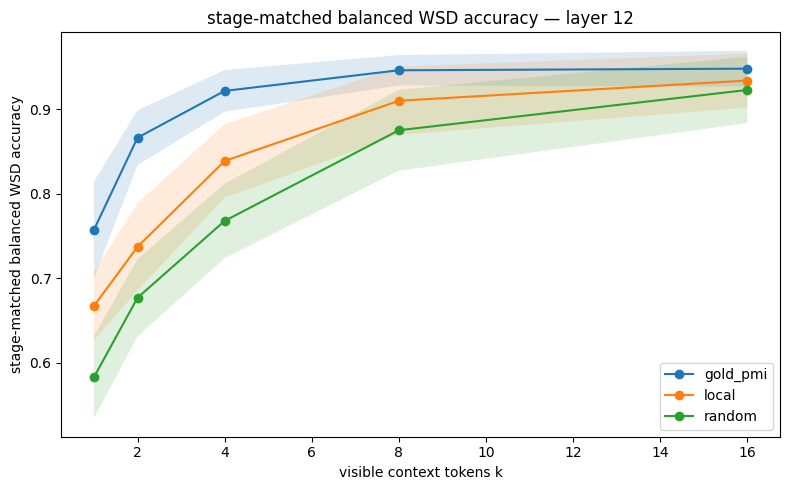

In [16]:
def aggregate_words(metric, layer=MAIN_LAYER):
    g = (
        summary[summary["layer"] == layer]
        .groupby(["strategy", "reveal_k"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(["strategy", "reveal_k"])
    )

    g["sem"] = (
        g["std"]
        / np.sqrt(
            np.maximum(g["count"], 1)
        )
    )

    return g


def plot_metric(
    metric,
    ylabel,
    filename,
    layer=MAIN_LAYER,
):
    agg = aggregate_words(
        metric,
        layer=layer,
    )

    plt.figure(figsize=(8, 5))

    for strategy, g in agg.groupby("strategy"):
        plt.plot(
            g["reveal_k"],
            g["mean"],
            marker="o",
            label=strategy,
        )

        plt.fill_between(
            g["reveal_k"],
            g["mean"] - g["sem"].fillna(0),
            g["mean"] + g["sem"].fillna(0),
            alpha=0.15,
        )

    plt.xlabel("visible context tokens k")
    plt.ylabel(ylabel)
    plt.title(
        f"{ylabel} — layer {layer}"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / filename,
        bbox_inches="tight",
    )
    plt.show()


plot_metric(
    "balanced_accuracy",
    "stage-matched balanced WSD accuracy",
    "01_balanced_accuracy.png",
)

## Plot 2 — contraction vs separation vs enrichment

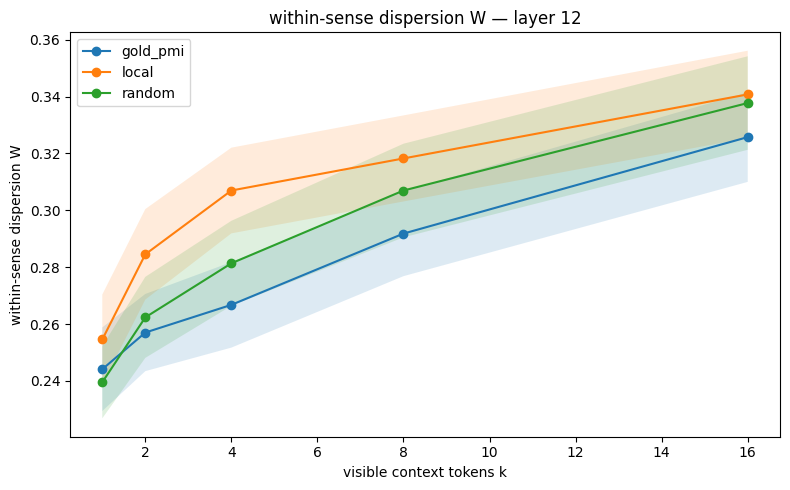

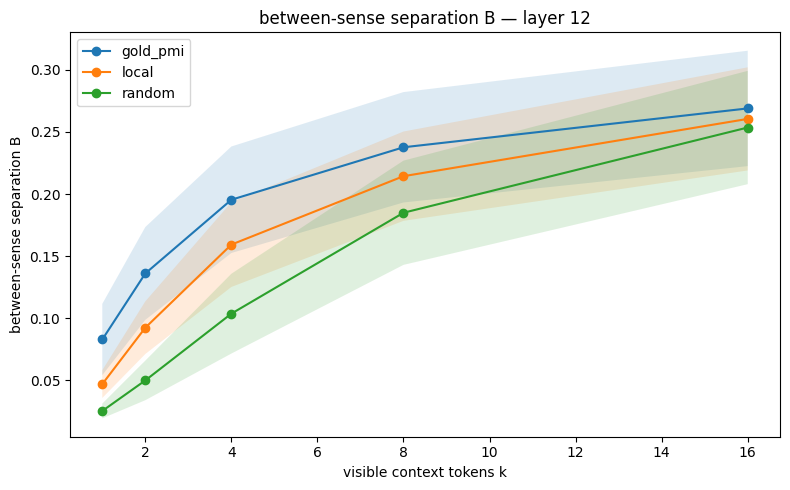

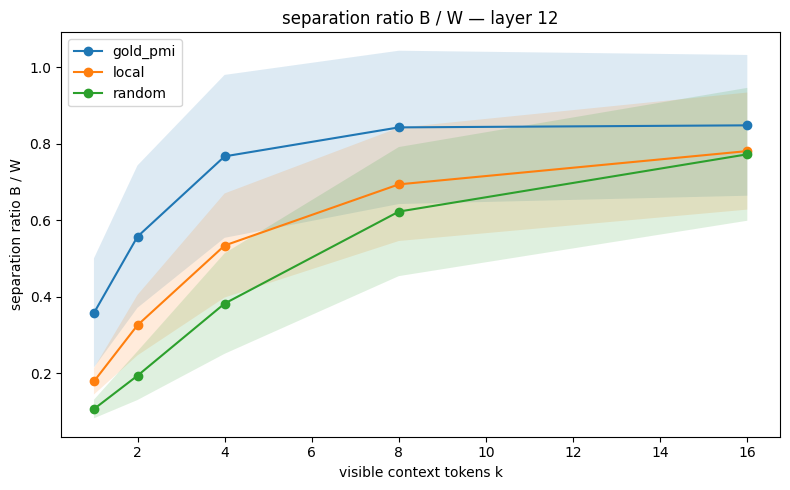

In [17]:
plot_metric(
    "within_dispersion",
    "within-sense dispersion W",
    "02_within_dispersion.png",
)

plot_metric(
    "between_separation",
    "between-sense separation B",
    "03_between_separation.png",
)

plot_metric(
    "separation_ratio",
    "separation ratio B / W",
    "04_separation_ratio.png",
)

## Plot 3 — direct paired effect curves

These plots remove the common context-length / mask-count effect.

Interpretation:

- \(\Delta W < 0\): contraction
- \(\Delta W pprox 0,\ \Delta B > 0\): separation
- \(\Delta W > 0,\ \Delta B > 0\): enrichment + separation

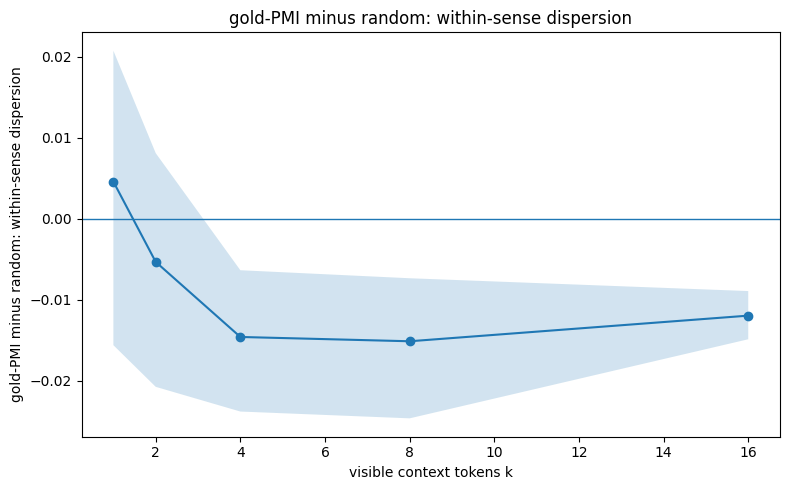

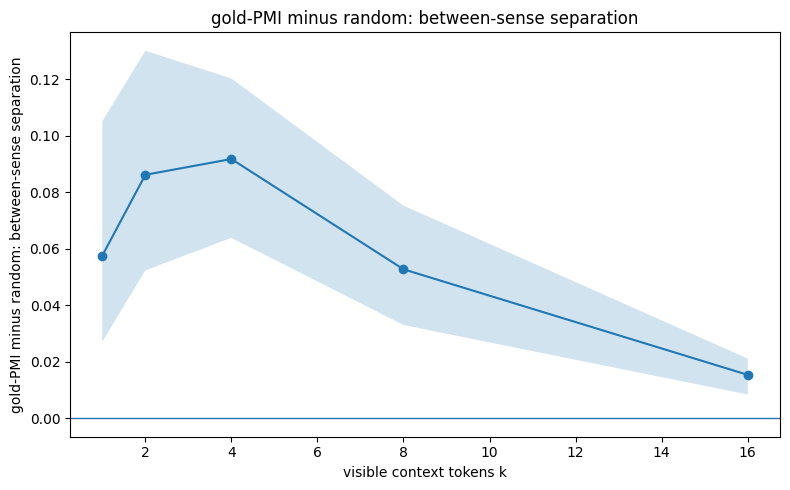

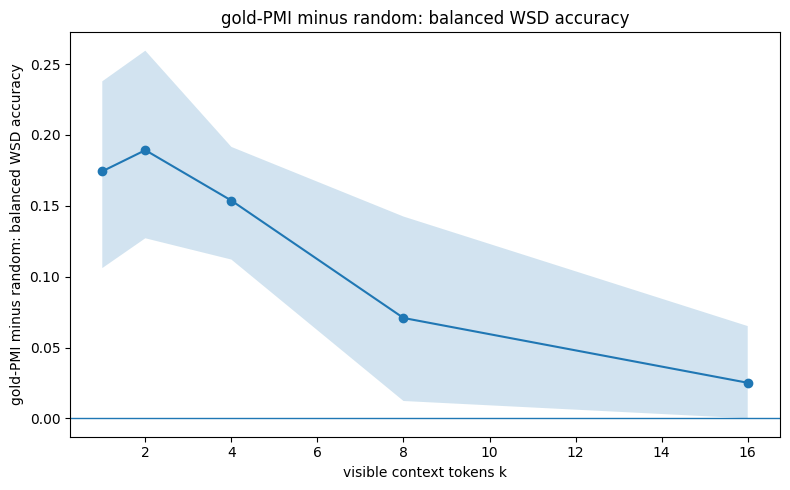

In [18]:
def plot_paired_effect(
    metric,
    ylabel,
    filename,
):
    e = effects[
        effects["metric"] == metric
    ].sort_values("reveal_k")

    plt.figure(figsize=(8, 5))

    plt.plot(
        e["reveal_k"],
        e["mean_delta"],
        marker="o",
    )

    plt.fill_between(
        e["reveal_k"],
        e["ci95_low"],
        e["ci95_high"],
        alpha=0.2,
    )

    plt.axhline(0, linewidth=1)
    plt.xlabel("visible context tokens k")
    plt.ylabel(ylabel)
    plt.title(ylabel)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / filename,
        bbox_inches="tight",
    )
    plt.show()


plot_paired_effect(
    "delta_within_dispersion",
    "gold-PMI minus random: within-sense dispersion",
    "05_delta_within.png",
)

plot_paired_effect(
    "delta_between_separation",
    "gold-PMI minus random: between-sense separation",
    "06_delta_between.png",
)

plot_paired_effect(
    "delta_balanced_accuracy",
    "gold-PMI minus random: balanced WSD accuracy",
    "07_delta_accuracy.png",
)

## Per-word mechanism table

This is useful because the average may hide lexical heterogeneity.

The classification below is descriptive and uses a small tolerance; the raw deltas remain the actual result.

In [19]:
TOL = 0.01

mechanism_rows = []

for _, row in paired.iterrows():
    dW = row["delta_within_dispersion"]
    dB = row["delta_between_separation"]
    dA = row["delta_balanced_accuracy"]

    if dA <= 0:
        mechanism = "no verified disambiguation gain"
    elif dW < -TOL:
        mechanism = "contraction"
    elif abs(dW) <= TOL and dB > TOL:
        mechanism = "separation"
    elif dW > TOL and dB > TOL:
        mechanism = "enrichment + separation"
    elif dW > TOL:
        mechanism = "enrichment"
    else:
        mechanism = "mixed"

    mechanism_rows.append({
        **row.to_dict(),
        "mechanism": mechanism,
    })

mechanisms = pd.DataFrame(mechanism_rows)

display(
    mechanisms[
        [
            "word",
            "reveal_k",
            "delta_balanced_accuracy",
            "delta_within_dispersion",
            "delta_between_separation",
            "delta_separation_ratio",
            "mechanism",
        ]
    ]
    .sort_values(["reveal_k", "word"])
)

,word,reveal_k,delta_balanced_accuracy,delta_within_dispersion,delta_between_separation,delta_separation_ratio,mechanism
0,bank,1,0.090909,0.035006,0.046517,0.152742,enrichment + separation
5,bass,1,0.037879,0.000414,0.018041,0.078606,separation
10,crane,1,0.203947,0.012503,0.023817,0.104762,enrichment + separation
15,java,1,0.235000,-0.039852,0.172233,0.861228,contraction
20,mole,1,0.200000,0.012830,0.035225,0.147195,enrichment + separation
25,spring,1,0.278539,0.006501,0.049653,0.163485,separation
1,bank,2,0.090909,0.008571,0.050994,0.178663,separation
6,bass,2,0.136364,-0.000467,0.040033,0.160931,separation
11,crane,2,0.138158,0.003133,0.061959,0.257983,separation
16,java,2,0.170000,-0.039145,0.190301,0.981186,contraction


## Layer robustness

The experiment is about context, not depth, but the effect should not depend on a single arbitrarily chosen layer.

We repeat the paired analysis at layers 4, 8, and 12.

,layer,reveal_k,delta_accuracy,delta_within,delta_between,delta_ratio
0,4,1,0.153380,0.013242,0.029402,0.213548
1,4,2,0.187548,0.009411,0.059083,0.389119
2,4,4,0.159848,-0.000903,0.073019,0.457322
3,4,8,0.106255,-0.005644,0.050950,0.308357
4,4,16,0.040489,-0.003289,0.019809,0.109596
5,8,1,0.165761,0.010381,0.049348,0.204877
6,8,2,0.191743,0.000861,0.080635,0.318149
7,8,4,0.168881,-0.009882,0.087064,0.339177
8,8,8,0.081566,-0.010042,0.052047,0.209761
9,8,16,0.022769,-0.007225,0.018023,0.075431


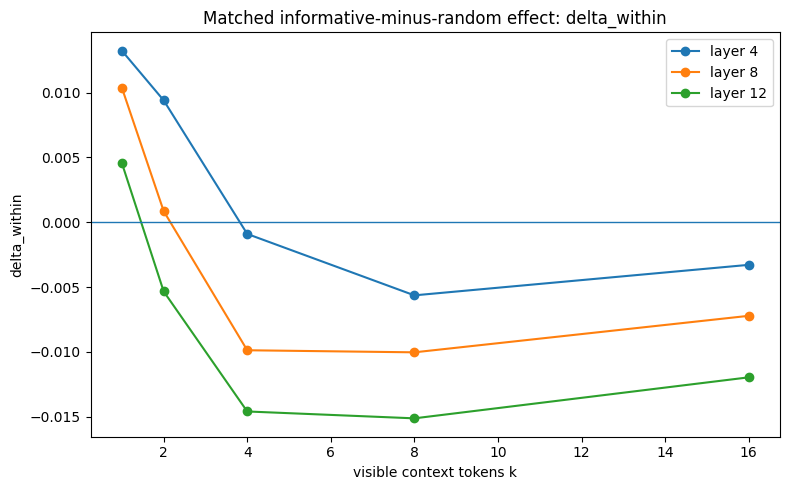

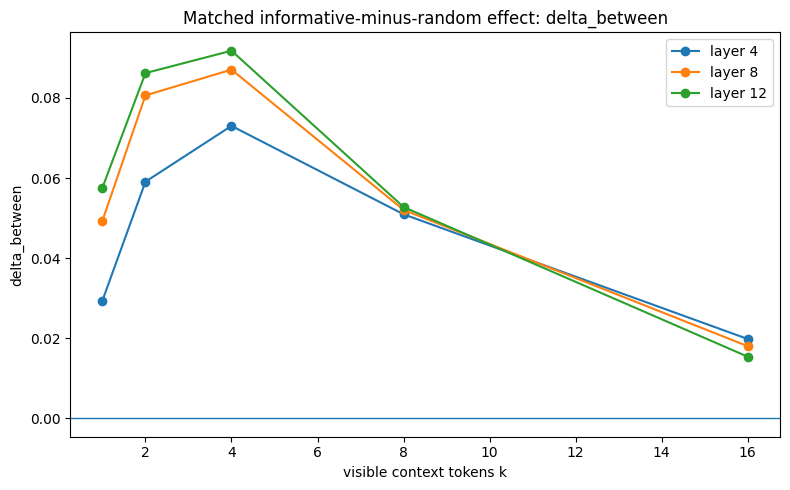

In [20]:
layer_effect_rows = []

for layer in LAYERS_TO_SAVE:
    p = paired_strategy_differences(
        summary,
        layer=layer,
    )

    for k, g in p.groupby("reveal_k"):
        layer_effect_rows.append({
            "layer": layer,
            "reveal_k": int(k),
            "delta_accuracy": g[
                "delta_balanced_accuracy"
            ].mean(),
            "delta_within": g[
                "delta_within_dispersion"
            ].mean(),
            "delta_between": g[
                "delta_between_separation"
            ].mean(),
            "delta_ratio": g[
                "delta_separation_ratio"
            ].mean(),
        })

layer_effects = pd.DataFrame(
    layer_effect_rows
)

display(layer_effects)

for metric in [
    "delta_within",
    "delta_between",
]:
    plt.figure(figsize=(8, 5))

    for layer, g in layer_effects.groupby("layer"):
        plt.plot(
            g["reveal_k"],
            g[metric],
            marker="o",
            label=f"layer {layer}",
        )

    plt.axhline(0, linewidth=1)
    plt.xlabel("visible context tokens k")
    plt.ylabel(metric)
    plt.title(
        f"Matched informative-minus-random effect: {metric}"
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"layer_{metric}.png",
        bbox_inches="tight",
    )
    plt.show()

## PCA visualization — matched condition

A single PCA basis is fit to both `gold_pmi` and `random` vectors for one word and one \(k\).

The plot is exploratory only. Quantitative claims use the full-dimensional metrics.

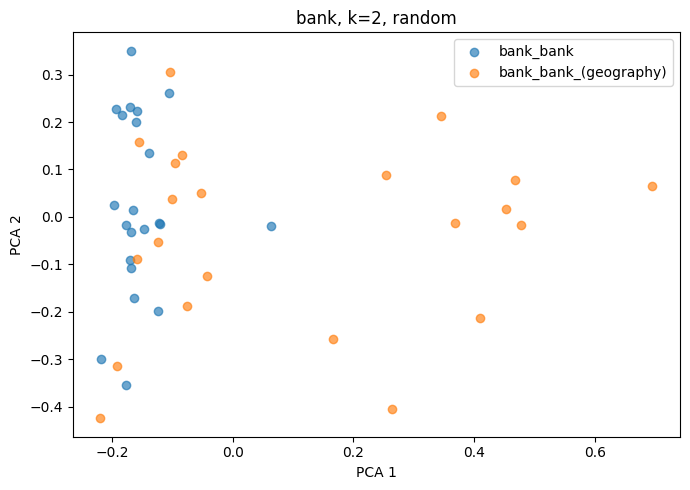

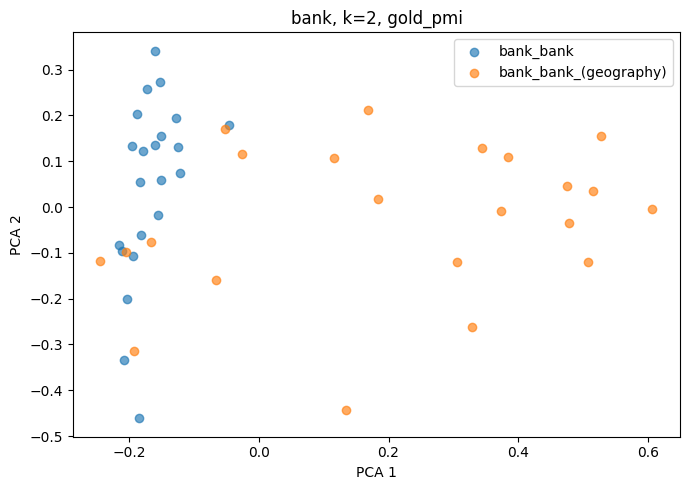

In [21]:
PLOT_WORD = (
    "bank"
    if "bank" in VALID_WORDS
    else VALID_WORDS[0]
)

PLOT_K = 2

mask = (
    (test_variants["word"] == PLOT_WORD)
    & (test_variants["reveal_k"] == PLOT_K)
    & (
        test_variants["strategy"]
        .isin(["gold_pmi", "random"])
    )
)

idx = np.where(mask.to_numpy())[0]

x = test_embeddings[MAIN_LAYER][idx]
meta = (
    test_variants.iloc[idx]
    .copy()
    .reset_index(drop=True)
)

xy = PCA(
    n_components=2,
    random_state=SEED,
).fit_transform(x)

meta["pc1"] = xy[:, 0]
meta["pc2"] = xy[:, 1]

for strategy in ["random", "gold_pmi"]:
    g = meta[
        meta["strategy"] == strategy
    ]

    plt.figure(figsize=(7, 5))

    for sense, gs in g.groupby("sense_name"):
        plt.scatter(
            gs["pc1"],
            gs["pc2"],
            alpha=0.65,
            label=sense,
        )

    plt.title(
        f"{PLOT_WORD}, k={PLOT_K}, {strategy}"
    )
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"pca_{PLOT_WORD}_k{PLOT_K}_{strategy}.png",
        bbox_inches="tight",
    )
    plt.show()

## What counts as an interesting V2 result?

### Strong separation evidence

At small matched reveal counts such as \(k=1,2,4\):

- informative context improves balanced WSD accuracy;
- \(\Delta B > 0\) consistently;
- \(\Delta W\) is near zero or much smaller than \(\Delta B\).

### Strong enrichment evidence

- informative context improves WSD;
- \(\Delta W > 0\);
- \(\Delta B > 0\), preferably by a larger amount.

### Contraction evidence

- informative context improves WSD;
- \(\Delta W < 0\) consistently.

### Stop condition

If informative context does not outperform matched random context in sense decodability, the manipulation failed and the geometry should not be interpreted.

In [22]:
# Save everything needed for analysis.

summary.to_csv(
    OUTPUT_DIR / "summary_metrics.csv",
    index=False,
)

paired.to_csv(
    OUTPUT_DIR / "paired_gold_minus_random.csv",
    index=False,
)

effects.to_csv(
    OUTPUT_DIR / "bootstrap_effects.csv",
    index=False,
)

mechanisms.to_csv(
    OUTPUT_DIR / "per_word_mechanisms.csv",
    index=False,
)

layer_effects.to_csv(
    OUTPUT_DIR / "layer_effects.csv",
    index=False,
)

train_sampling.to_csv(
    OUTPUT_DIR / "train_sampling.csv",
    index=False,
)

test_sampling.to_csv(
    OUTPUT_DIR / "test_sampling.csv",
    index=False,
)

config = {
    "run_mode": RUN_MODE,
    "dataset": DATASET_ID,
    "model": MODEL_NAME,
    "valid_words": VALID_WORDS,
    "reveal_counts": REVEAL_COUNTS,
    "strategies": STRATEGIES,
    "layers": LAYERS_TO_SAVE,
    "main_layer": MAIN_LAYER,
    "seed": SEED,
    "max_train_per_sense": MAX_TRAIN_PER_SENSE,
    "max_test_per_sense": MAX_TEST_PER_SENSE,
    "min_train_per_sense": MIN_TRAIN_PER_SENSE,
    "min_test_per_sense": MIN_TEST_PER_SENSE,
}

with open(
    OUTPUT_DIR / "config.json",
    "w",
) as f:
    json.dump(config, f, indent=2)

print(
    sorted(
        p.name
        for p in OUTPUT_DIR.iterdir()
    )
)

['01_balanced_accuracy.png', '02_within_dispersion.png', '03_between_separation.png', '04_separation_ratio.png', '05_delta_within.png', '06_delta_between.png', '07_delta_accuracy.png', 'bootstrap_effects.csv', 'config.json', 'layer_delta_between.png', 'layer_delta_within.png', 'layer_effects.csv', 'paired_gold_minus_random.csv', 'pca_bank_k2_gold_pmi.png', 'pca_bank_k2_random.png', 'per_word_mechanisms.csv', 'summary_metrics.csv', 'test_sampling.csv', 'train_sampling.csv']


In [23]:
# Pack results for download.
import shutil

archive = shutil.make_archive(
    "semantic_disambiguation_geometry_v2_results",
    "zip",
    root_dir=OUTPUT_DIR,
)

print("archive:", archive)

archive: /kaggle/working/semantic_disambiguation_geometry_v2_results.zip


## After the pilot

If V2 reproduces the previous separation signal:

1. switch to `RUN_MODE="full"` for all eligible CoarseWSD-20 words;
2. repeat with `roberta-base`;
3. replace `[MASK]` manipulation with a natural-context control to test mask artifacts;
4. add a human-graded ambiguity resource such as RAW-C;
5. only then consider writing the result as a paper-level claim.

The first pilot's numerical results should **not** be reused because its sampling was invalid.